## Storm Occurrence Prediction using Random Forest Classifier

In this section, we aim to predict **whether or not a tropical storm will occur** using a **Random Forest Classifier**. This is Part 1 of our modeling phase.

We classify a storm as occurring when its wind speed exceeds 34 knots. This aligns with standard meteorological definitions of a tropical storm. The goal is to build a model that uses features such as **CO₂ emissions, time, and temperature anomalies** to predict the occurrence of a storm.


### Load the Dataset and Prepare Features

We use the `completed_dataset_for_IS_project_25.csv` file, which contains the merged and cleaned dataset with added engineered features.

The features used for this prediction include:
- **CO2 emission (Tons)**
- **Year**
- **MONTH**
- **DAY**
- **Surface Temperature Anomalies** (monthly)


In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Load the merged dataset
df = pd.read_csv("completed_dataset_for_IS_project_25.csv")

# Create binary target column: storm_occurred
# Threshold: Wind speed > 34 knots indicates a storm
df['storm_occurred'] = df['WIND_KTS'].apply(lambda x: 1 if x > 34 else 0)

# Check distribution
print(df['storm_occurred'].value_counts())

# Preview to verify
df[['WIND_KTS', 'storm_occurred']].head()


storm_occurred
1    41196
0    11460
Name: count, dtype: int64


,WIND_KTS,storm_occurred
0,70,1
1,80,1
2,80,1
3,90,1
4,40,1


### Create Binary Classification Label

We define a new column `storm_occurred`:
- `1` if `WIND_KTS > 34`
- `0` otherwise

This transforms the dataset into a binary classification problem.

In [23]:
# Features selected from domain knowledge
features = ['Year', 'MONTH', 'DAY', 'CO2 emission (Tons)', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
            'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

X = df[features]
y = df['storm_occurred']

# Split into training (70%) and test (30%) for now
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

### Model Training - Random Forest Classifier

We split the dataset into training and test sets using a standard 80-20 split. Then, we train a Random Forest Classifier with default parameters to predict whether a storm will occur based on the selected features.


In [24]:
# Train model
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Evaluate on test set
y_pred = clf.predict(X_test)

### Model Evaluation

We evaluate our classifier using:
- **Accuracy Score**
- **Classification Report** (Precision, Recall, F1-Score)
- **Confusion Matrix**


              precision    recall  f1-score   support

           0       0.76      0.70      0.73      3438
           1       0.92      0.94      0.93     12359

    accuracy                           0.89     15797
   macro avg       0.84      0.82      0.83     15797
weighted avg       0.89      0.89      0.89     15797



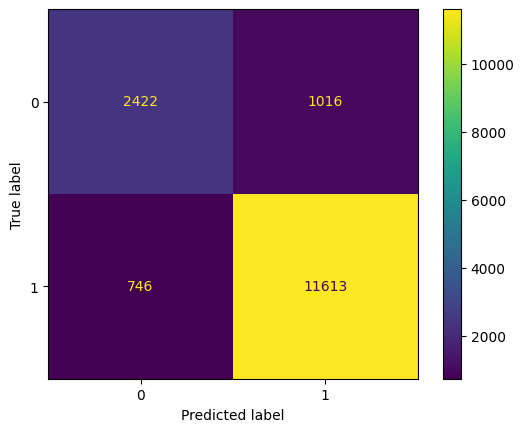

In [25]:
# Classification metrics
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

### Feature Importance Visualization

We plot the most important features used by the Random Forest model to understand which variables contribute most to storm occurrence prediction.

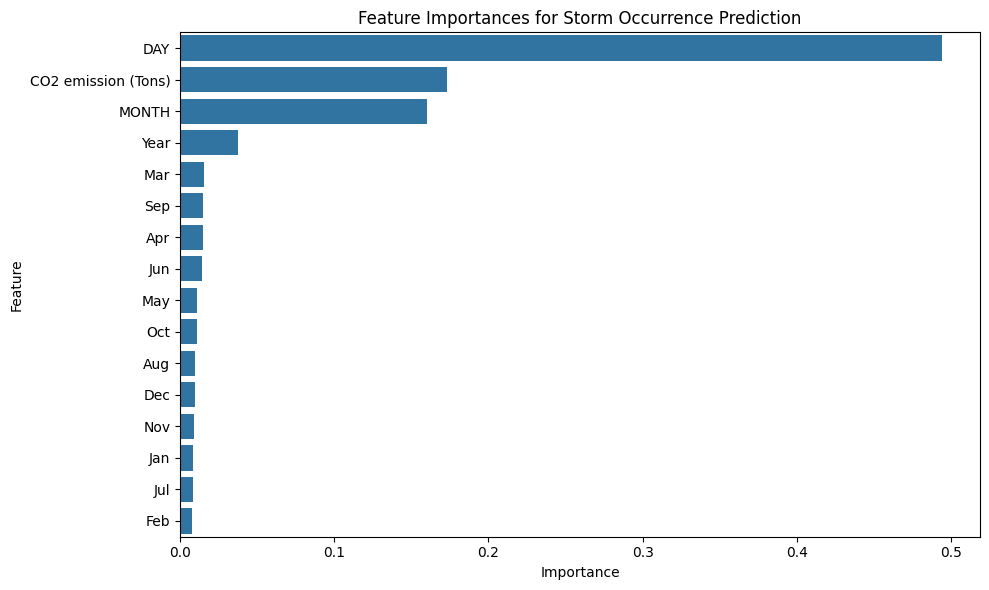

In [27]:
# Feature importances
importances = clf.feature_importances_
feature_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
feature_df.sort_values(by='Importance', ascending=False, inplace=True)

# Plot
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feature_df)
plt.title("Feature Importances for Storm Occurrence Prediction")
plt.tight_layout()
plt.show()

### Save Trained Model

We save the trained model to a `.pkl` file so it can be reused for deployment or integration into the overall project.


In [28]:
joblib.dump(clf, "storm_occurrence_rf_model.pkl")

['storm_occurrence_rf_model.pkl']

## Summary

This section of the project successfully built a classification model to predict the occurrence of tropical storms based on environmental and temporal variables. Random Forest was selected for its robustness and interpretability.

**Next step**: In Part 2, we will build a **Random Forest Regressor** to predict **storm intensity** for instances where a storm is predicted to occur.
